Saving global_climate_energy_2020_2024.csv to global_climate_energy_2020_2024.csv
Dataset Loaded Successfully!

         date  country  avg_temperature  humidity  co2_emission  \
0  2020-01-01  Germany            28.29     31.08        212.63   
1  2020-01-02  Germany            28.38     37.94        606.05   
2  2020-01-03  Germany            28.74     57.67        268.72   
3  2020-01-04  Germany            26.66     51.34        167.32   
4  2020-01-05  Germany            26.81     65.38        393.89   

   energy_consumption  renewable_share  urban_population  \
0            11348.75            14.42             76.39   
1             4166.64             5.63             86.26   
2             4503.80            14.20             75.92   
3             3259.13            13.84             63.15   
4             7023.72             6.93             76.02   

   industrial_activity_index  energy_price  
0                      51.22         83.93  
1                      78.27      

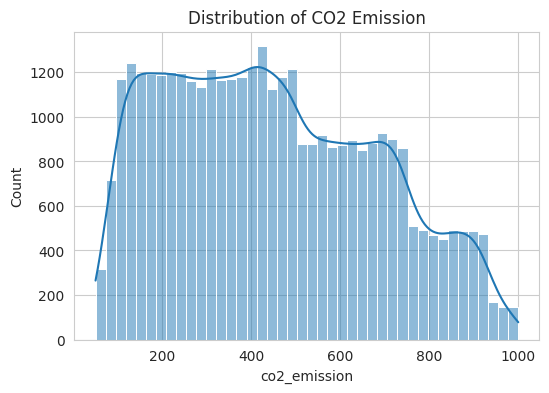

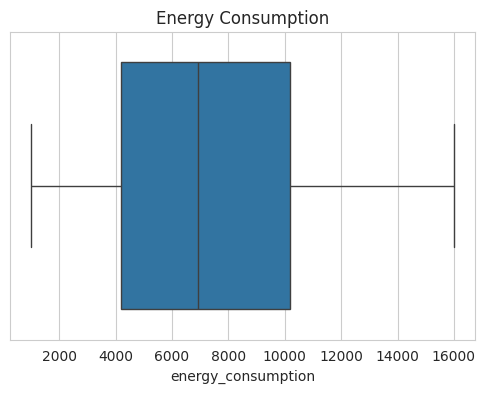

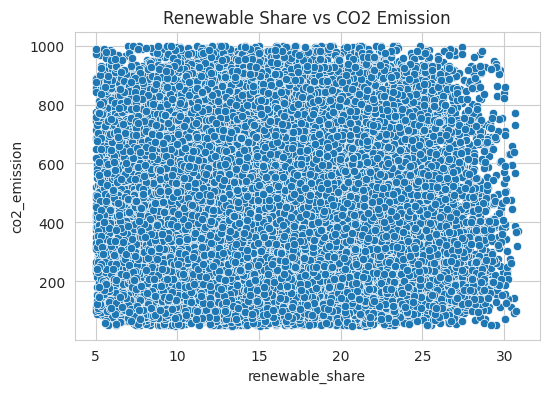

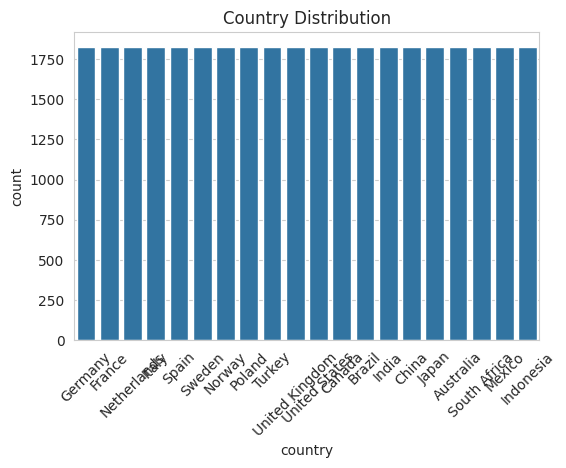

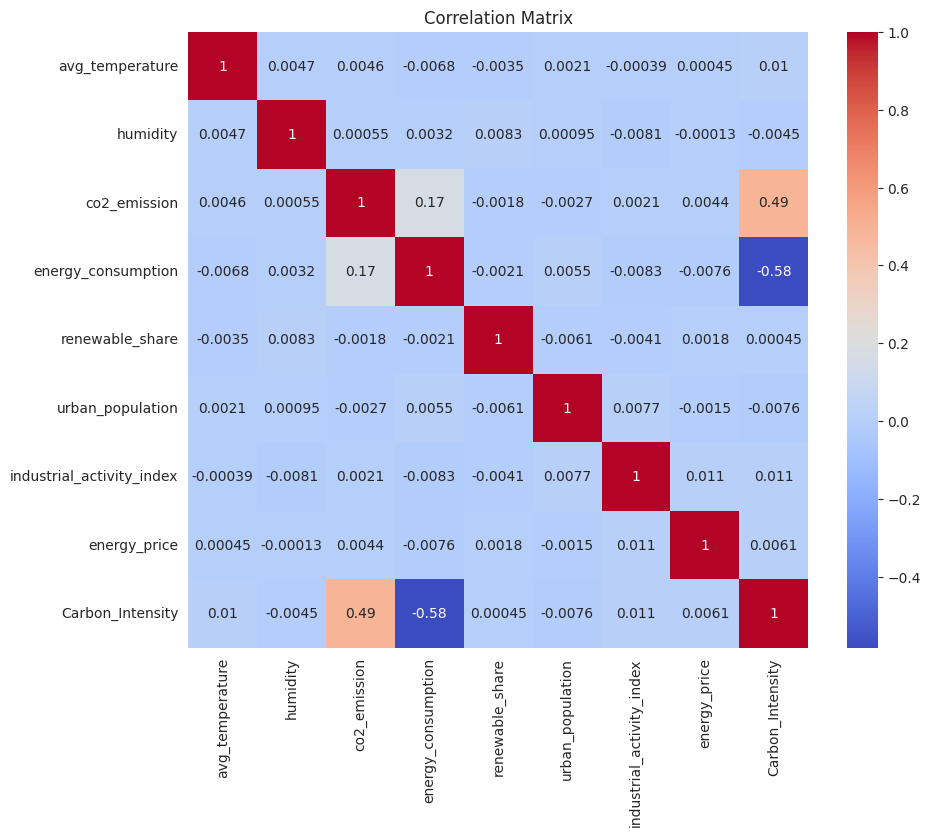


Numerical Columns Scaled Successfully

Country Column Encoded Successfully

Processed Dataset
         date  country  avg_temperature  humidity  co2_emission  \
0  2020-01-01        5         1.459658 -1.669751     -0.995019   
1  2020-01-02        5         1.468589 -1.273284      0.683697   
2  2020-01-03        5         1.504313 -0.133011     -0.755684   
3  2020-01-04        5         1.297905 -0.498846     -1.188356   
4  2020-01-05        5         1.312790  0.312580     -0.221586   

   energy_consumption  renewable_share  urban_population  \
0            1.097179        -0.285690          0.162845   
1           -0.847149        -1.933383          1.304509   
2           -0.755874        -0.326929          0.108480   
3           -1.092828        -0.394412         -1.368626   
4           -0.073685        -1.689697          0.120047   

   industrial_activity_index  energy_price  Carbon_Intensity  
0                  -1.093369     -0.637481         -0.900158  
1              

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from google.colab import files
from sklearn.preprocessing import StandardScaler, LabelEncoder

uploaded = files.upload()

filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

print("Dataset Loaded Successfully!\n")

# Dataset Preview
print(df.head())

print("\nShape of Dataset")
print(df.shape)

print("\nColumn Names")
print(df.columns)

print("\nDataset Information")
print(df.info())

print("\nStatistical Summary")
print(df.describe())

print("\nGENERALISATIONS\n")

print("""
1. Each row represents climate and energy data for a country on a specific date.

2. Average Temperature and Humidity represent climatic conditions.

3. CO2 Emission measures environmental pollution.

4. Energy Consumption shows the total energy used.

5. Renewable Share represents the percentage of renewable energy used.

6. Urban Population indicates the level of urbanisation.

7. Industrial Activity Index represents industrial growth.

8. Energy Price indicates the cost of energy.
""")


print("\nFEATURE RELATIONSHIPS\n")

print("""
• Higher Industrial Activity generally increases Energy Consumption.

• Higher Energy Consumption often increases CO2 Emissions.

• Higher Renewable Share can help reduce CO2 Emissions.

• Urban Population generally increases Energy Demand.

• Temperature and Humidity may influence Energy Consumption.

• Energy Price may affect Energy Consumption patterns.
""")

df["Carbon_Intensity"] = df["co2_emission"] / df["energy_consumption"]

print("\nFeature Engineering Completed")
print("Created new feature: Carbon_Intensity")


print("\nMissing Values Before Cleaning")
print(df.isnull().sum())

numeric = df.select_dtypes(include=np.number).columns
categorical = df.select_dtypes(include="object").columns

df[numeric] = df[numeric].fillna(df[numeric].median())

for col in categorical:
    df[col] = df[col].fillna("Unknown")

print("\nMissing Values After Cleaning")
print(df.isnull().sum())


sns.set_style("whitegrid")

plt.figure(figsize=(6,4))
sns.histplot(df["co2_emission"], kde=True)
plt.title("Distribution of CO2 Emission")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x=df["energy_consumption"])
plt.title("Energy Consumption")
plt.show()

plt.figure(figsize=(6,4))
sns.scatterplot(
    data=df,
    x="renewable_share",
    y="co2_emission"
)
plt.title("Renewable Share vs CO2 Emission")
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="country")
plt.xticks(rotation=45)
plt.title("Country Distribution")
plt.show()

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


scaler = StandardScaler()

numeric_columns = df.select_dtypes(include=np.number).columns

df[numeric_columns] = scaler.fit_transform(df[numeric_columns])

print("\nNumerical Columns Scaled Successfully")


encoder = LabelEncoder()

df["country"] = encoder.fit_transform(df["country"])

print("\nCountry Column Encoded Successfully")


print("\nProcessed Dataset")
print(df.head())


print("\nSUMMARY\n")

print("""
1. Imported the Climate & Energy dataset.

2. Explored the dataset using:
   • head()
   • info()
   • describe()
   • shape
   • columns

3. Analysed relationships between climate, renewable energy and CO2 emissions.

4. Created a new feature called Carbon_Intensity.

5. Missing numerical values were filled using the median.

6. Missing categorical values were filled using 'Unknown'.

7. Visualised the dataset using:
   • Histogram
   • Boxplot
   • Scatter Plot
   • Count Plot
   • Heatmap

8. Applied StandardScaler on numerical columns.

9. Applied LabelEncoder on the Country column.

10. The dataset is now cleaned and ready for machine learning analysis.
""")

# Save Processed Dataset

df.to_csv("processed_green_skill_dataset.csv", index=False)

print("\nProcessed dataset saved as 'processed_green_skill_dataset.csv'")